# Feature Enriching Tests 

Adding grid-based and knn-based features to CSV df output from segmentation runs. Testing on both mock data and real CSV output. 

Real file tested (file path): /standard/vol191/siegristlab/Microsam_Segmentation/jobruns/24h/AkhGal4 x OR Susie/Scrib488 Dpn555 EdU 647/Animal 1.lif/Series001-(3,93,512,512)-dog-1.0-12.0-threshold-0.1/Features_Dpn.csv


### kNN feature enrichment 

function parameters: df, k, radius, cluster quantile

output: df 

features added: 
- nearest_neighbor_label
- nearest_neighbor_distance: distance to single closest object
- knn_mean_distance: average distance to the k nearest neighbors
- knn_density: continuous density score. higher = more locally crowded (closer neighbors), lower = more isolated. calculation: k / mean_distance_to_neighbors. combination of centroid dimensions. 
- neighbors_within_radius
- cluster_flag: 1 if in cluster, 0 if not
- density_threshold_used: dynamically computed from current sample (take top x% densest objects and call them clustered)
- density_quantile_used: more robust than hardcoding a threshold



In [6]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

In [7]:
def add_neighbor_features(
    df,
    centroid_cols=("centroid-0", "centroid-1", "centroid-2"),
    k=5,
    radius=75,
    cluster_quantile=0.75,
):
    df = df.copy()

    coords = df[list(centroid_cols)].to_numpy(dtype=float)
    labels = df["label"].to_numpy()

    n_neighbors = min(k + 1, len(df))

    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(coords)

    distances, indices = nn.kneighbors(coords)

    # remove self neighbor
    neighbor_distances = distances[:, 1:]
    neighbor_indices = indices[:, 1:]

    df["nearest_neighbor_label"] = labels[neighbor_indices[:, 0]]
    df["nearest_neighbor_distance"] = neighbor_distances[:, 0]
    df["knn_mean_distance"] = neighbor_distances.mean(axis=1)
    df["knn_density"] = k / (df["knn_mean_distance"] + 1e-9)

    radius_neighbors = nn.radius_neighbors(coords, radius=radius, return_distance=False)
    df["neighbors_within_radius"] = [len(neigh) - 1 for neigh in radius_neighbors]

    threshold = df["knn_density"].quantile(cluster_quantile)
    df["cluster_flag"] = df["knn_density"] >= threshold
    df["density_threshold_used"] = threshold
    df["density_quantile_used"] = cluster_quantile

    return df

#### Test 1: mock data (using only label + centroids)

Mock centroid data with intentionally structured patterns:
- dense clusters (`cluster_1`, `cluster_2`)
- edge cluster (`edge_cluster`)
- isolated objects

Used to sanity check that kNN and grid-based density features behave as expected before testing on real segmentation outputs

In [8]:
# create data 
np.random.seed(42)

cluster_1 = np.random.normal(loc=[0, 0, 0], scale=[1, 2, 2], size=(12, 3))
cluster_2 = np.random.normal(loc=[50, 200, 200], scale=[2, 5, 5], size=(10, 3))
edge_cluster = np.random.normal(loc=[400, 50, 50], scale=[2, 4, 4], size=(8, 3))

isolated = np.array([
    [100, 500, 500],
    [150, 600, 600],
    [200, 700, 700],
    [250, 800, 800],
    [300, 900, 900],
    [75, 350, 100],
    [125, 450, 300],
])

coords = np.vstack([cluster_1, cluster_2, edge_cluster, isolated])

df = pd.DataFrame(coords, columns=["centroid-0", "centroid-1", "centroid-2"])
df.insert(0, "label", np.arange(1, len(df) + 1))

df.head()

,label,centroid-0,centroid-1,centroid-2
0,1,0.496714,-0.276529,1.295377
1,2,1.523030,-0.468307,-0.468274
2,3,1.579213,1.534869,-0.938949
3,4,0.542560,-0.926835,-0.931460
4,5,0.241962,-3.826560,-3.449836


In [9]:
# test 
enriched = add_neighbor_features(
    df,
    k=3,
    radius=20,
    cluster_quantile=0.75
)

enriched.sort_values("knn_density", ascending=False).head(15)

,label,centroid-0,centroid-1,centroid-2,nearest_neighbor_label,nearest_neighbor_distance,knn_mean_distance,knn_density,neighbors_within_radius,cluster_flag,density_threshold_used,density_quantile_used
9,10,0.375698,-1.201277,-0.583387,4,0.473620,1.193364,2.513901,11,True,0.91106,0.75
3,4,0.542560,-0.926835,-0.931460,10,0.473620,1.247873,2.404091,11,True,0.91106,0.75
8,9,-0.544383,0.221845,-2.301987,8,0.639381,1.417157,2.116914,11,True,0.91106,0.75
1,2,1.523030,-0.468307,-0.468274,4,1.177332,1.531065,1.959421,11,True,0.91106,0.75
7,8,-0.225776,0.135056,-2.849496,9,0.639381,1.578035,1.901099,11,True,0.91106,0.75
5,6,-0.562288,-2.025662,0.628495,10,1.740140,2.031925,1.476432,11,True,0.91106,0.75
0,1,0.496714,-0.276529,1.295377,2,2.049529,2.099261,1.429074,11,True,0.91106,0.75
11,12,-1.057711,1.645090,-2.441687,9,1.519423,2.109367,1.422228,11,True,0.91106,0.75
2,3,1.579213,1.534869,-0.938949,2,2.058496,2.524716,1.188252,11,True,0.91106,0.75
6,7,-0.908024,-2.824607,2.931298,6,2.461859,3.292867,0.911060,11,True,0.91106,0.75


#### Test 2: Real segmentation output 

In [10]:
df = pd.read_csv('/standard/vol191/siegristlab/Microsam_Segmentation/jobruns/24h/AkhGal4 x OR Susie/Scrib488 Dpn555 EdU 647/Animal 1.lif/Series001-(3,93,512,512)-dog-1.0-12.0-threshold-0.1/Features_Dpn.csv')
df.columns

Index(['label', 'centroid-0', 'centroid-1', 'centroid-2', 'bbox-0', 'bbox-1',
       'bbox-2', 'bbox-3', 'bbox-4', 'bbox-5', 'sphericity', 'aspect_ratio',
       'volume', 'Green +', 'dice Green +', 'Blue +', 'dice Blue +'],
      dtype='object')

In [11]:
df.head()

,label,centroid-0,centroid-1,centroid-2,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,sphericity,aspect_ratio,volume,Green +,dice Green +,Blue +,dice Blue +
0,5,0.000000,118.168817,57.906596,0.0,282.0,103.0,1.0,447.0,288.0,NaN,NaN,584.511795,False,0.0,False,0.052332
1,6,-0.999928,56.199533,58.266143,1.0,164.0,177.0,2.0,216.0,216.0,NaN,NaN,115.893804,False,0.0,False,0.000000
2,8,-4.235994,87.826101,141.159743,3.0,281.0,461.0,6.0,308.0,481.0,8.153255,0.463630,73.930702,False,0.0,True,0.343371
3,10,-8.752499,126.401349,51.291267,5.0,411.0,163.0,13.0,435.0,181.0,6.164704,0.475074,172.895185,False,0.0,False,0.067705
4,11,-7.082481,126.629846,58.161660,5.0,414.0,187.0,10.0,431.0,202.0,6.114603,0.654911,65.105843,False,0.0,False,0.000000


In [12]:
enriched = add_neighbor_features(
    df,
    k=5,
    radius=50,
    cluster_quantile=0.75
)
enriched.columns

Index(['label', 'centroid-0', 'centroid-1', 'centroid-2', 'bbox-0', 'bbox-1',
       'bbox-2', 'bbox-3', 'bbox-4', 'bbox-5', 'sphericity', 'aspect_ratio',
       'volume', 'Green +', 'dice Green +', 'Blue +', 'dice Blue +',
       'nearest_neighbor_label', 'nearest_neighbor_distance',
       'knn_mean_distance', 'knn_density', 'neighbors_within_radius',
       'cluster_flag', 'density_threshold_used', 'density_quantile_used'],
      dtype='object')

In [13]:
print(sum(enriched['cluster_flag']==True))
print(len(enriched))

71
281


Note: notably small number of clustered features (71/281)
but 281 is likely too many NBs anyway so good sign to point toward future refiltering/reclassification

### Grid-based Feature Enrichment

function parameters: df, grid_shape 
- df expected columns: label, centroid-0, centroid-1, centroid-2 (x,y,z)

output: df 

features added: 
- grid_z
- grid_y
- grid_x
- grid_cell_count
- grid_density_ratio


assigns grid cells according to `grid_shape`.

`grid_shape=(5,10,10)` means split z into 5 bins, y into 10 bins, x into 10 bins, for a 3D grid 

In [14]:
# function definition 
def add_grid_density_features(
    df,
    grid_shape=(5, 10, 10),
):

    df = df.copy()

    coords = df[
        ["centroid-0", "centroid-1", "centroid-2"]
    ].to_numpy(dtype=float)

    mins = coords.min(axis=0)
    maxs = coords.max(axis=0)

    ranges = np.where(maxs - mins == 0, 1, maxs - mins)

    normalized = (coords - mins) / ranges

    grid_indices = np.floor(
        normalized * np.array(grid_shape)
    ).astype(int)

    grid_indices = np.minimum(
        grid_indices,
        np.array(grid_shape) - 1
    )

    df["grid_z"] = grid_indices[:, 0]
    df["grid_y"] = grid_indices[:, 1]
    df["grid_x"] = grid_indices[:, 2]

    grid_counts = (
        df.groupby(["grid_z", "grid_y", "grid_x"])
        .size()
        .rename("grid_cell_count")
        .reset_index()
    )

    df = df.merge(
        grid_counts,
        on=["grid_z", "grid_y", "grid_x"],
        how="left"
    )

    total_cells = np.prod(grid_shape)

    avg_objects_per_cell = len(df) / total_cells

    df["grid_density_ratio"] = (
        df["grid_cell_count"] / avg_objects_per_cell
    )

    return df

#### Test 1: mock data 

In [15]:
# --------------------------------------------------
# Create mock centroid data with obvious structure
# --------------------------------------------------

np.random.seed(42)

# Dense cluster near origin
cluster_1 = np.random.normal(
    loc=[0, 0, 0],
    scale=[1, 2, 2],
    size=(15, 3)
)

# Medium-density cluster
cluster_2 = np.random.normal(
    loc=[50, 200, 200],
    scale=[3, 8, 8],
    size=(12, 3)
)

# Sparse edge cluster
cluster_3 = np.random.normal(
    loc=[400, 50, 50],
    scale=[5, 10, 10],
    size=(8, 3)
)

# Isolated objects
isolated = np.array([
    [100, 500, 500],
    [150, 650, 650],
    [200, 800, 800],
    [250, 950, 950],
    [300, 1100, 1100],
])

# Combine everything
coords = np.vstack([
    cluster_1,
    cluster_2,
    cluster_3,
    isolated
])

# Build dataframe
df = pd.DataFrame(
    coords,
    columns=[
        "centroid-0",
        "centroid-1",
        "centroid-2"
    ]
)

# Add labels
df.insert(0, "label", np.arange(1, len(df) + 1))

print(df.head())
print()
print("Total objects:", len(df))

   label  centroid-0  centroid-1  centroid-2
0      1    0.496714   -0.276529    1.295377
1      2    1.523030   -0.468307   -0.468274
2      3    1.579213    1.534869   -0.938949
3      4    0.542560   -0.926835   -0.931460
4      5    0.241962   -3.826560   -3.449836

Total objects: 40


In [16]:
# test 
grid_df = add_grid_density_features(
    df,
    grid_shape=(2, 3, 3)
)

grid_df.head(40)

,label,centroid-0,centroid-1,centroid-2,grid_z,grid_y,grid_x,grid_cell_count,grid_density_ratio
0,1,0.496714,-0.276529,1.295377,0,0,0,27,12.15
1,2,1.523030,-0.468307,-0.468274,0,0,0,27,12.15
2,3,1.579213,1.534869,-0.938949,0,0,0,27,12.15
3,4,0.542560,-0.926835,-0.931460,0,0,0,27,12.15
4,5,0.241962,-3.826560,-3.449836,0,0,0,27,12.15
5,6,-0.562288,-2.025662,0.628495,0,0,0,27,12.15
6,7,-0.908024,-2.824607,2.931298,0,0,0,27,12.15
7,8,-0.225776,0.135056,-2.849496,0,0,0,27,12.15
8,9,-0.544383,0.221845,-2.301987,0,0,0,27,12.15
9,10,0.375698,-1.201277,-0.583387,0,0,0,27,12.15


#### Test 2: real segmentation output

In [17]:
df = pd.read_csv('/standard/vol191/siegristlab/Microsam_Segmentation/jobruns/24h/AkhGal4 x OR Susie/Scrib488 Dpn555 EdU 647/Animal 1.lif/Series001-(3,93,512,512)-dog-1.0-12.0-threshold-0.1/Features_Dpn.csv')

In [18]:
grid_df_real = add_grid_density_features(
    df,
    grid_shape=(5, 10, 10)
)

grid_df_real.head(40)
#len(grid_df_real)

,label,centroid-0,centroid-1,centroid-2,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,...,volume,Green +,dice Green +,Blue +,dice Blue +,grid_z,grid_y,grid_x,grid_cell_count,grid_density_ratio
0,5,0.000000,118.168817,57.906596,0.0,282.0,103.0,1.0,447.0,288.0,...,584.511795,False,0.000000,False,0.052332,4,8,3,3,5.338078
1,6,-0.999928,56.199533,58.266143,1.0,164.0,177.0,2.0,216.0,216.0,...,115.893804,False,0.000000,False,0.000000,4,3,3,1,1.779359
2,8,-4.235994,87.826101,141.159743,3.0,281.0,461.0,6.0,308.0,481.0,...,73.930702,False,0.000000,True,0.343371,4,6,9,2,3.558719
3,10,-8.752499,126.401349,51.291267,5.0,411.0,163.0,13.0,435.0,181.0,...,172.895185,False,0.000000,False,0.067705,4,8,3,3,5.338078
4,11,-7.082481,126.629846,58.161660,5.0,414.0,187.0,10.0,431.0,202.0,...,65.105843,False,0.000000,False,0.000000,4,8,3,3,5.338078
5,12,-8.271233,140.859086,18.611888,5.0,436.0,0.0,12.0,501.0,127.0,...,1731.923487,True,0.735075,False,0.061355,4,9,0,1,1.779359
6,13,-7.378593,12.376927,127.894178,6.0,32.0,419.0,10.0,51.0,434.0,...,49.167068,False,0.000000,False,0.000000,4,0,8,1,1.779359
7,14,-7.524237,13.081434,137.400510,6.0,33.0,450.0,10.0,56.0,466.0,...,79.964023,False,0.000000,True,0.583300,4,0,9,3,5.338078
8,17,-7.925210,39.132233,65.808033,7.0,118.0,210.0,10.0,143.0,230.0,...,89.779427,False,0.000000,False,0.000000,4,2,4,3,5.338078
9,18,-8.052720,87.429019,141.614176,7.0,280.0,464.0,10.0,303.0,482.0,...,64.205347,False,0.000000,True,0.128484,4,6,9,2,3.558719


##### Visualize resulting grid 

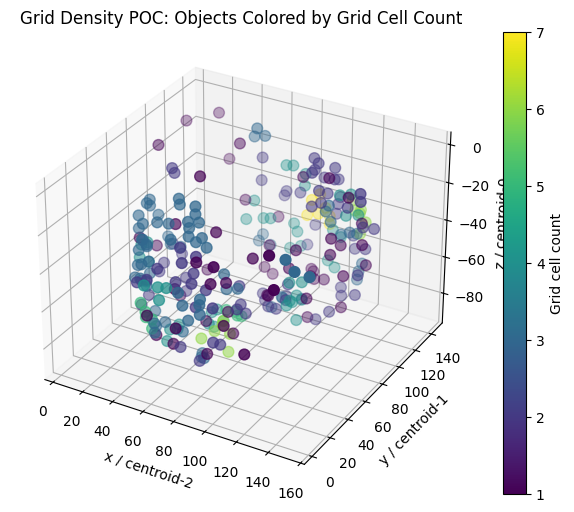

In [19]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    grid_df_real["centroid-2"],   # x
    grid_df_real["centroid-1"],   # y
    grid_df_real["centroid-0"],   # z
    c=grid_df_real["grid_cell_count"],
    s=60
)

ax.set_xlabel("x / centroid-2")
ax.set_ylabel("y / centroid-1")
ax.set_zlabel("z / centroid-0")
ax.set_title("Grid Density POC: Objects Colored by Grid Cell Count")

plt.colorbar(scatter, ax=ax, label="Grid cell count")
plt.show()